## Python version

In [1]:
# Python versions
import sys, site
print("Python:", sys.executable)
print("User site:", site.getusersitepackages())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")

Python: /home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/bin/python
User site: /home/nicolas/.local/lib/python3.12/site-packages
Site-packages: ['/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/local/lib/python3.12/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/dist-packages']


## Librairies

In [2]:
# System and files
import os
import pickle
from tqdm import tqdm
from pathlib import Path
from dataclasses import dataclass

# Files and data

import numpy as np
import polars as pl
import pyarrow.parquet as pq
from dataclasses import fields

# Vizualization
from matplotlib import pyplot as plt
from tqdm import tqdm

# Personal package
import nucleo.io.plots_1D as nclp
plt.rcParams["font.size"] = 16

## File Reading

In [3]:
def match_folder(folder_name, params):
    """
    Check if all parameters are present in the folder name.
    Handles integer/float scientific notation formats.
    """
    for key, value in params.items():

        if isinstance(value, (int, float)):
            possible_values = [
                str(value),
                f"{value:.1e}"
            ]
        else:
            possible_values = [str(value)]

        if not any(f"{key}={v}__" in folder_name for v in possible_values):
            return False

    return True



def find_parquet_and_load(
        base_folder=Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "NUCLEO__PSMN__2026-06-19",
        **params
) -> pl.DataFrame | None:
    """
    Search recursively for a folder matching parameters,
    then load the first parquet file found inside.
    """

    # List first-level folders
    subdirs = [
        os.path.join(base_folder, d)
        for d in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, d))
    ]

    for subdir in tqdm(subdirs, desc="Loading subfiles", unit="subfiles"):

        for dirpath, dirnames, filenames in os.walk(subdir):

            for dirname in dirnames:

                if match_folder(dirname, params):

                    subdir_path = os.path.join(dirpath, dirname)

                    print(f"\nCorresponding subfile found:")
                    print(subdir_path)

                    # Search parquet files
                    parquet_files = [
                        f for f in os.listdir(subdir_path)
                        if f.endswith(".parquet")
                    ]

                    if len(parquet_files) == 0:
                        print("No parquet file found in folder.")
                        return None

                    pq_path = os.path.join(subdir_path, parquet_files[0])

                    try:
                        df_polars = pl.read_parquet(pq_path)

                        pl.Config.set_tbl_cols(len(df_polars.columns))

                        print(f"File loaded successfully: {parquet_files[0]}")
                        print(f"Shape: {df_polars.shape}")

                        return df_polars

                    except Exception as e:
                        print("Error loading parquet:", e)
                        return None

    print("No sub-folders match the specified criteria.")
    return None



# ==========================
# Parameters
# ==========================

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",

    "land": "periodic",
    "s": 150,
    "l": 100,
    "bpmin": 0,

    "mu": 150,
    "theta": 65,

    "nt": 10_000,
}


# ==========================
# Load different simulations
# ==========================


params1 = params.copy()
params1["l"]        = 50
params1["mu"]       = 250
params1["theta"]    = 1

params2 = params.copy()
params2["l"]        = 50
params2["mu"]       = 300
params2["theta"]    = 10

params3 = params.copy()
params3["l"]        = 50
params3["mu"]       = 400
params3["theta"]    = 5

params4 = params.copy()
params4["l"]        = 100
params4["mu"]       = 500
params4["theta"]    = 40


df1 = find_parquet_and_load(**params1)
df2 = find_parquet_and_load(**params2)
df3 = find_parquet_and_load(**params3)
df4 = find_parquet_and_load(**params4)

Loading subfiles:  58%|█████▊    | 111/192 [00:01<00:00, 81.39subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/nucleo__lshigh__2/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=50__bpmin=0__mu=250__theta=1__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=50__bpmin=0__mu=250__theta=1__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:  62%|██████▎   | 120/192 [00:01<00:00, 81.51subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/nucleo__lshigh__3/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=50__bpmin=0__mu=300__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=50__bpmin=0__mu=300__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:  60%|█████▉    | 115/192 [00:01<00:00, 80.05subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/nucleo__lshigh__4/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=50__bpmin=0__mu=400__theta=5__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=50__bpmin=0__mu=400__theta=5__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:  28%|██▊       | 54/192 [00:00<00:01, 77.69subfiles/s] 


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/nucleo__lshigh__14/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=100__bpmin=0__mu=500__theta=40__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=100__bpmin=0__mu=500__theta=40__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


## Extracting Values

In [4]:
from dataclasses import dataclass
import numpy as np
import polars as pl


@dataclass(slots=True, kw_only=True, frozen=True)
class SimulationData:

    # ===========================
    # Algorithm
    # ===========================

    algo: str
    fact: bool
    mode: str
    dstr: bool

    # ===========================
    # Inputs
    # ===========================

    land: str

    s: int
    l: int
    bpmin: int

    mu: float
    theta: float

    alphaf: float
    alphao: float
    beta: float

    rcapt: float
    rrest: float

    alphac: float
    alphad: float
    alphar: float

    krel: float
    Kp: float
    Kz: float

    c_linker: float
    c_nucleo: float

    Lmin: int
    Lmax: int

    bps: int
    origin: int

    tmax: int
    dt: float

    times: np.ndarray

    binx: int
    bint: int

    bound_l: float
    bound_m: float
    bound_h: float

    alpha0: float

    nt: int

    # ===========================
    # Obstacle
    # ===========================

    s_mean: float
    l_mean: float

    alpha_mean_a: np.ndarray
    alpha_mean_v: float
    alpha_mean_c: float

    obstacles: np.ndarray

    s_points: np.ndarray
    s_distrib: np.ndarray

    l_points: np.ndarray
    l_distrib: np.ndarray
    l_view: np.ndarray

    # ===========================
    # Probabilities
    # ===========================

    p: np.ndarray

    # ===========================
    # Results
    # ===========================

    v_mean: float
    v_med: float

    v_mean_th: float
    v_mean_th_eff: float

    results: np.ndarray
    results_mean: np.ndarray
    results_med: np.ndarray
    results_std: np.ndarray

    # ===========================
    # Fitting
    # ===========================

    vf: float
    Cf: float
    wf: float

    vf_std: float
    Cf_std: float
    wf_std: float

    # ===========================
    # Instantaneous speeds
    # ===========================

    vi_mean: float
    vi_med: float
    vi_mp: float

    vc_mean: float
    vc_med: float

    # ===========================
    # Matrices
    # ===========================

    t_matrix: np.ndarray
    x_matrix: np.ndarray

    # ===========================
    # Histograms
    # ===========================

    pos_hist: np.ndarray

    xbj_points: np.ndarray
    xbj_distrib: np.ndarray

    tbj_points: np.ndarray
    tbj_distrib: np.ndarray

    fpt_distrib: np.ndarray
    fpt_number: np.ndarray

    dx_points: np.ndarray
    dx_distrib: np.ndarray
    dx_mean: float
    dx_med: float
    dx_mp: float

    dt_points: np.ndarray
    dt_distrib: np.ndarray
    dt_mean: float
    dt_med: float
    dt_mp: float

    vi_points: np.ndarray
    vi_distrib: np.ndarray

    # ===========================
    # Plot tools
    # ===========================

    xt_over_t: np.ndarray
    G: np.ndarray

    @classmethod
    def from_polars(cls, df: pl.DataFrame):

        if df.height == 0:
            raise ValueError("Empty DataFrame")

        row = df.row(0, named=True)

        # Conversion automatique des listes en ndarray
        for key, value in row.items():
            if isinstance(value, list):
                row[key] = np.asarray(value)

        return cls(**row)
    
sim_data_1 = SimulationData.from_polars(df1)
sim_data_2 = SimulationData.from_polars(df2)
sim_data_3 = SimulationData.from_polars(df3)
sim_data_4 = SimulationData.from_polars(df4)

print("Values loaded")

Values loaded


## Illustrating

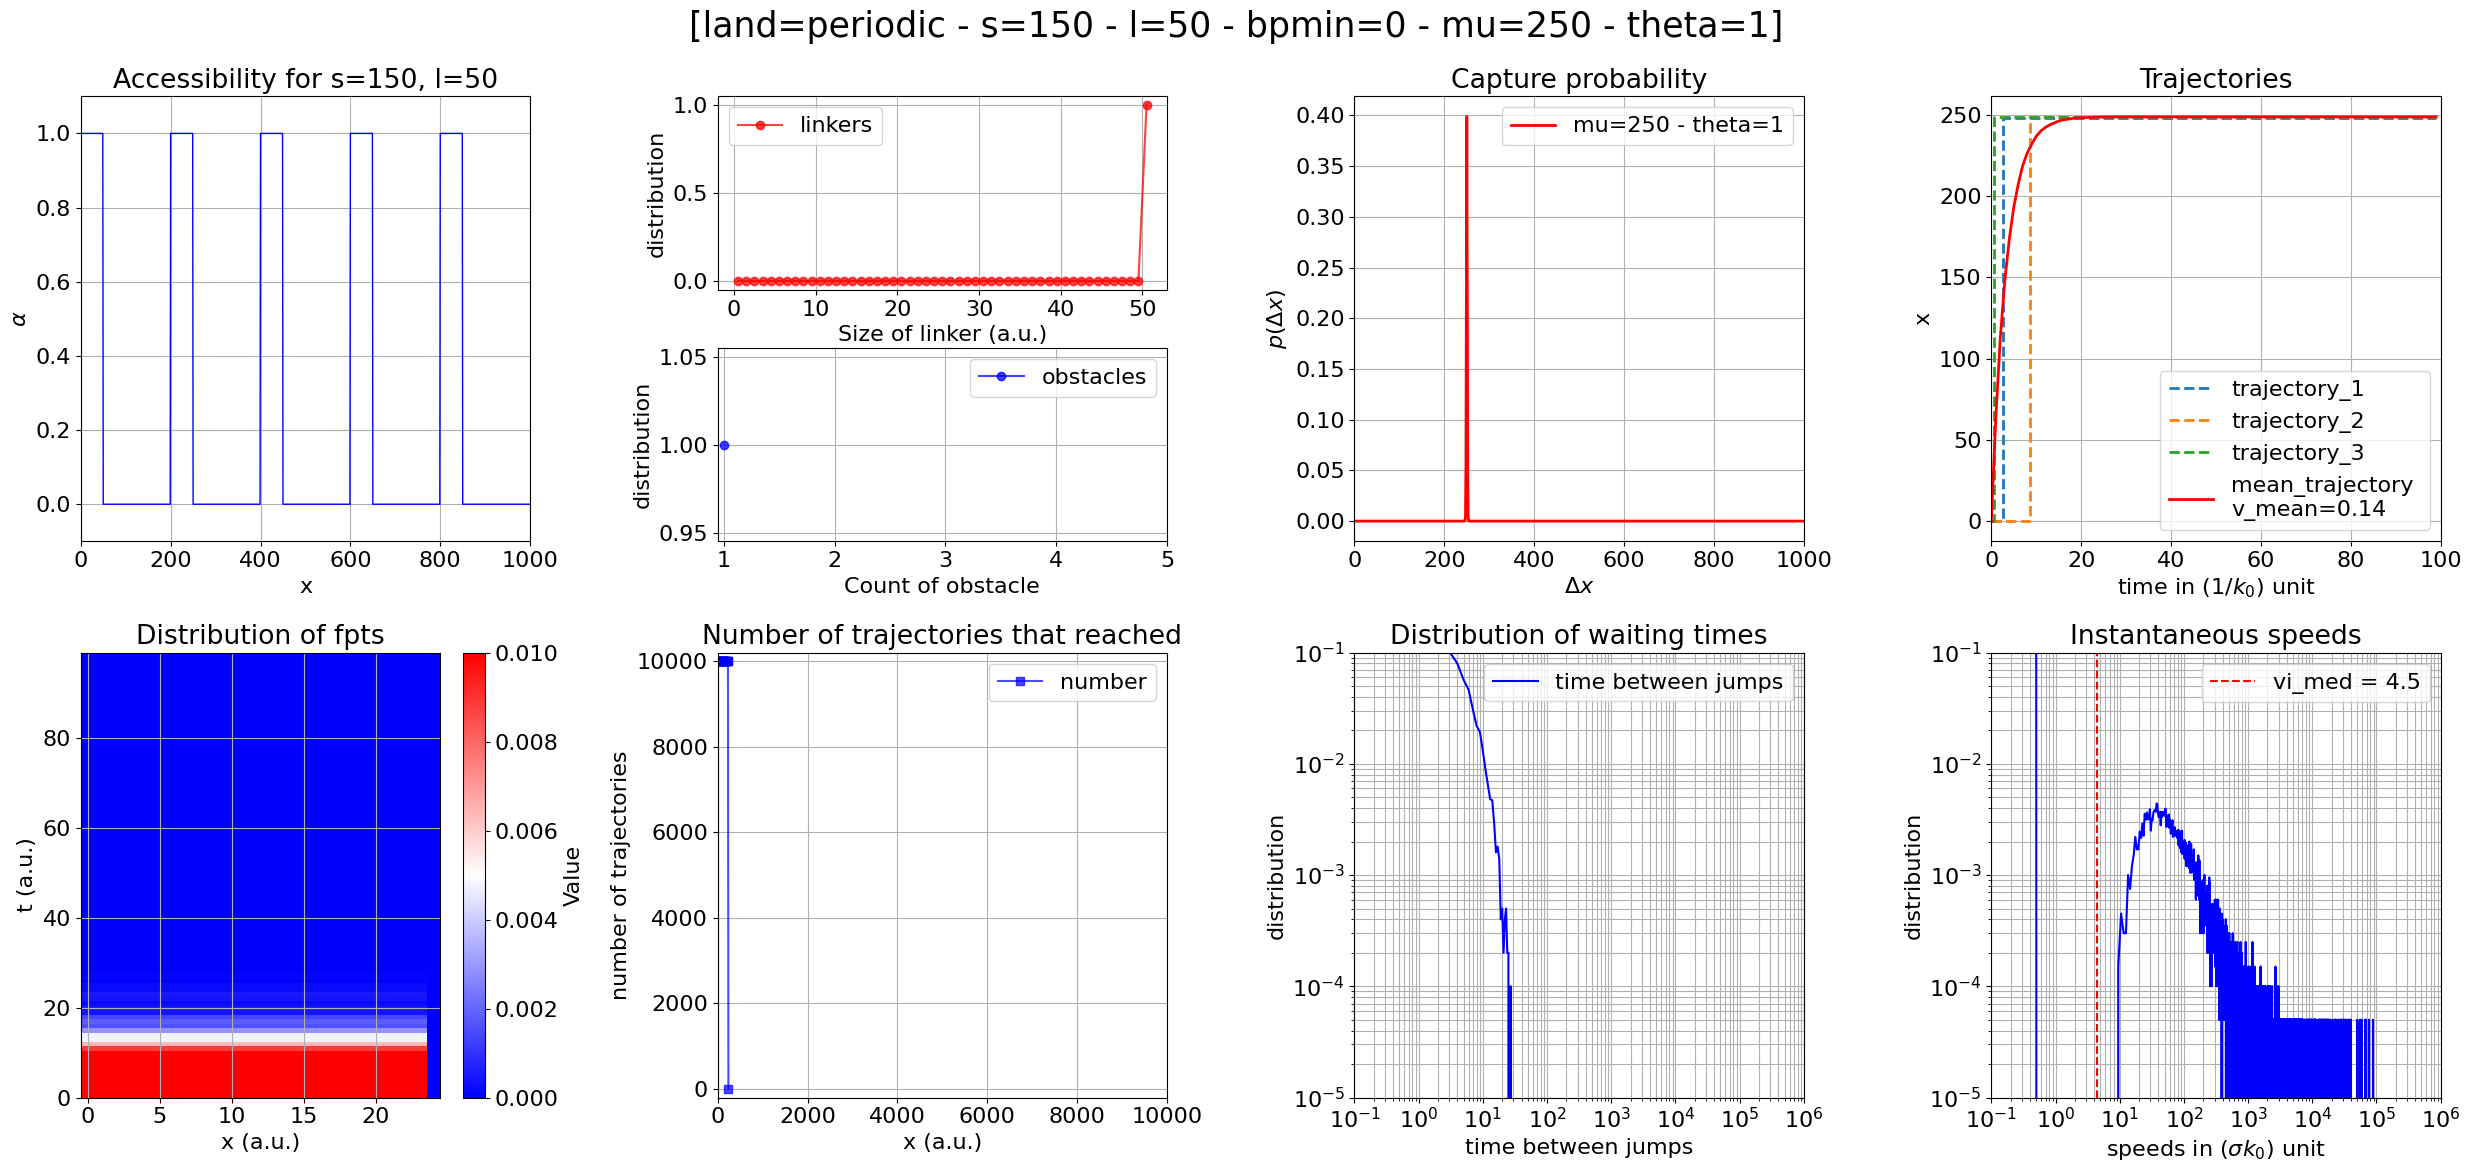

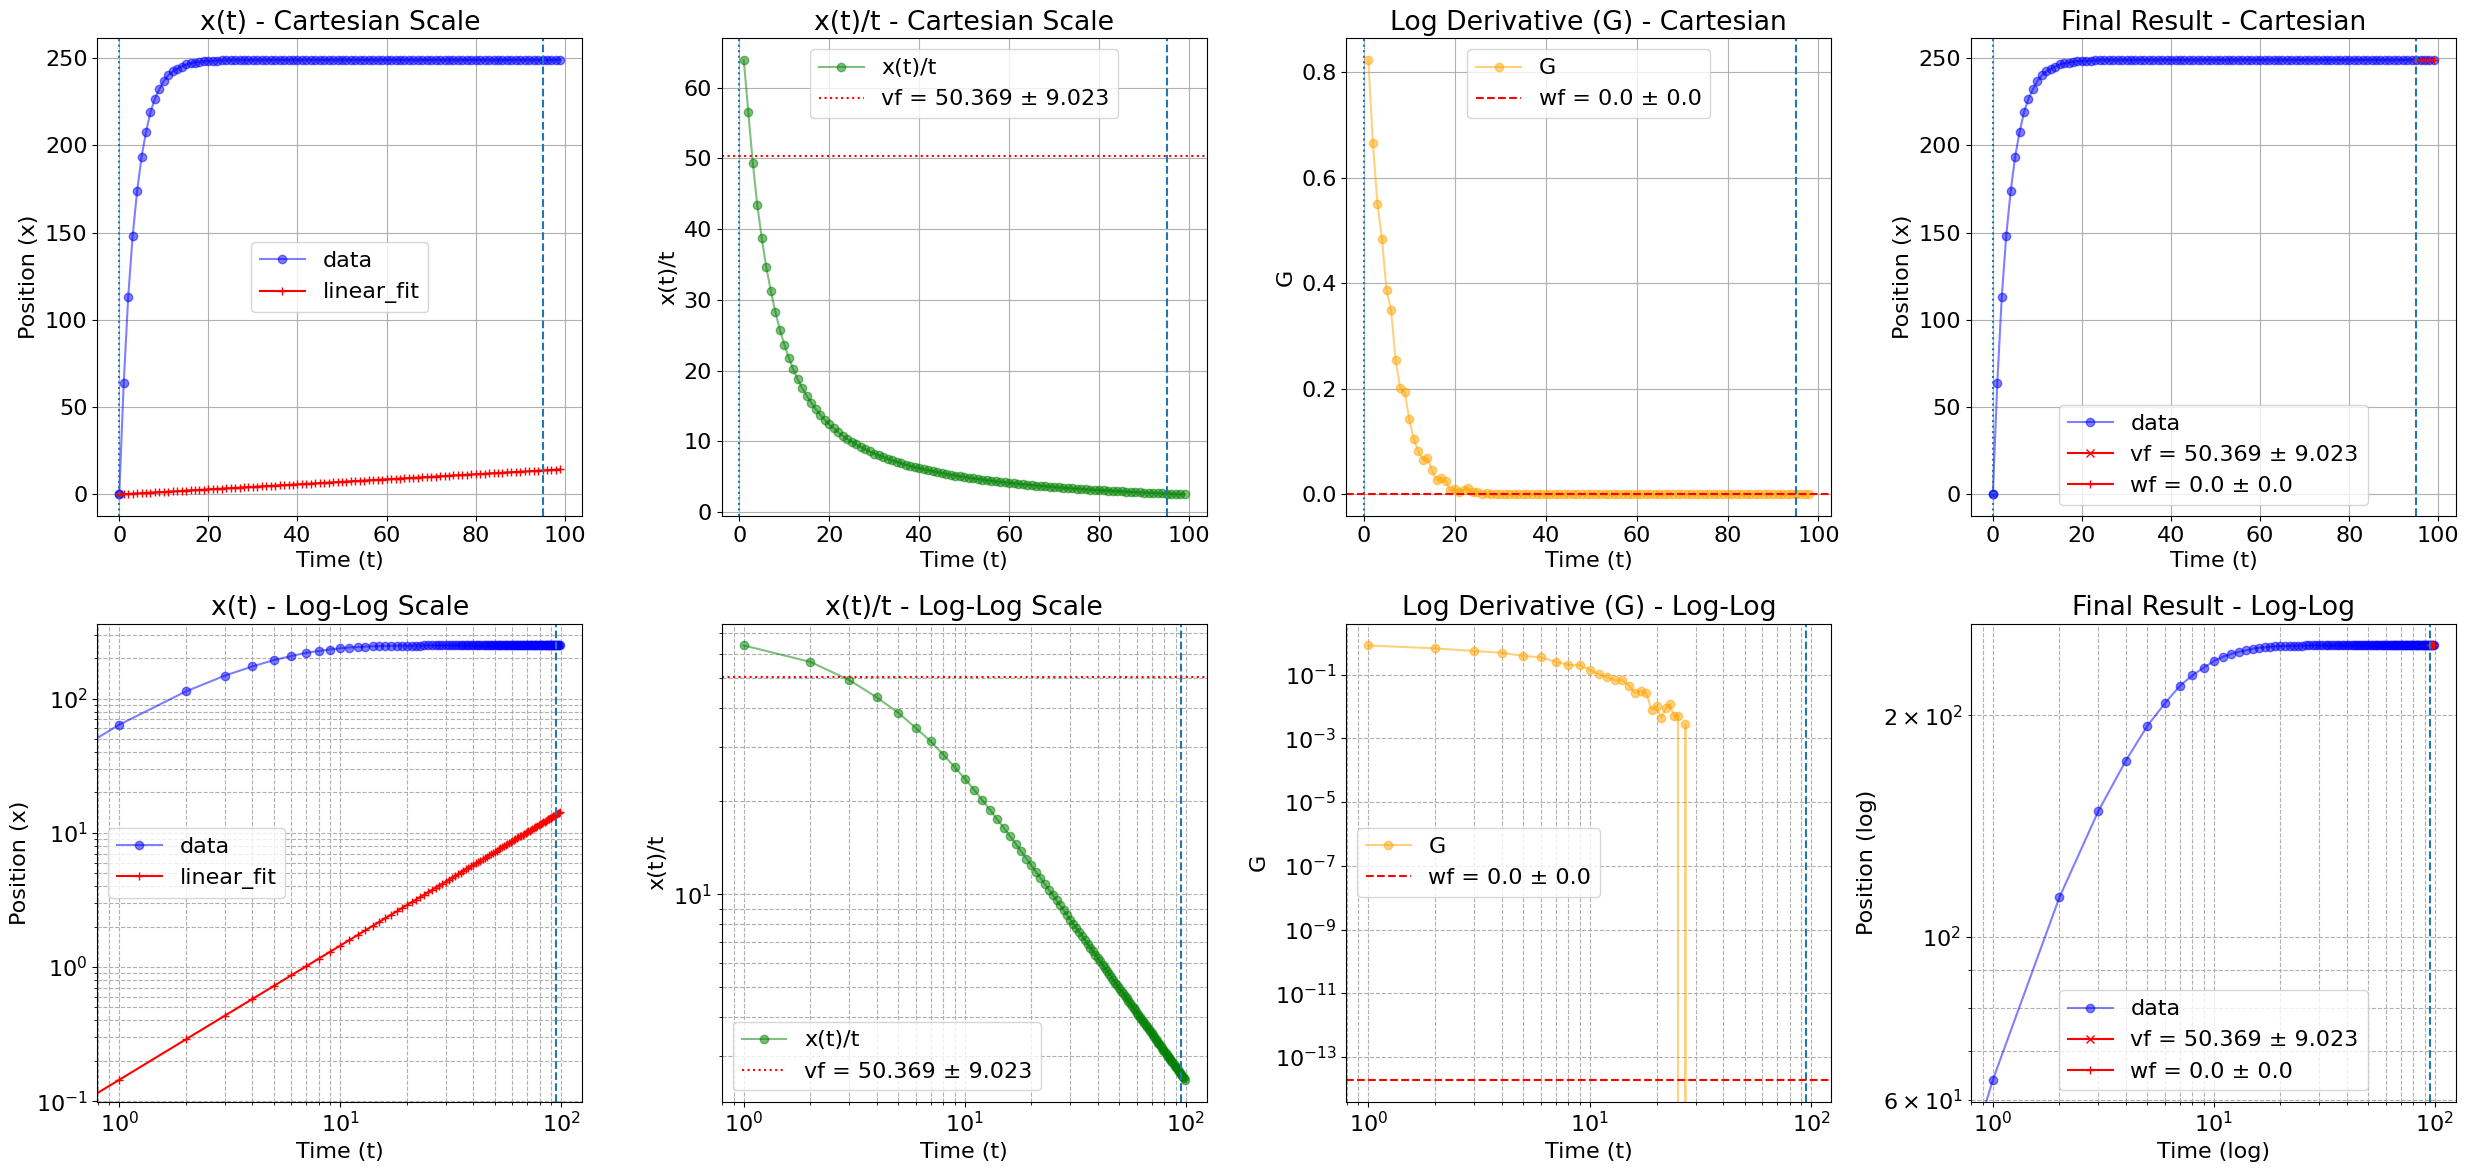

<Figure size 640x480 with 0 Axes>

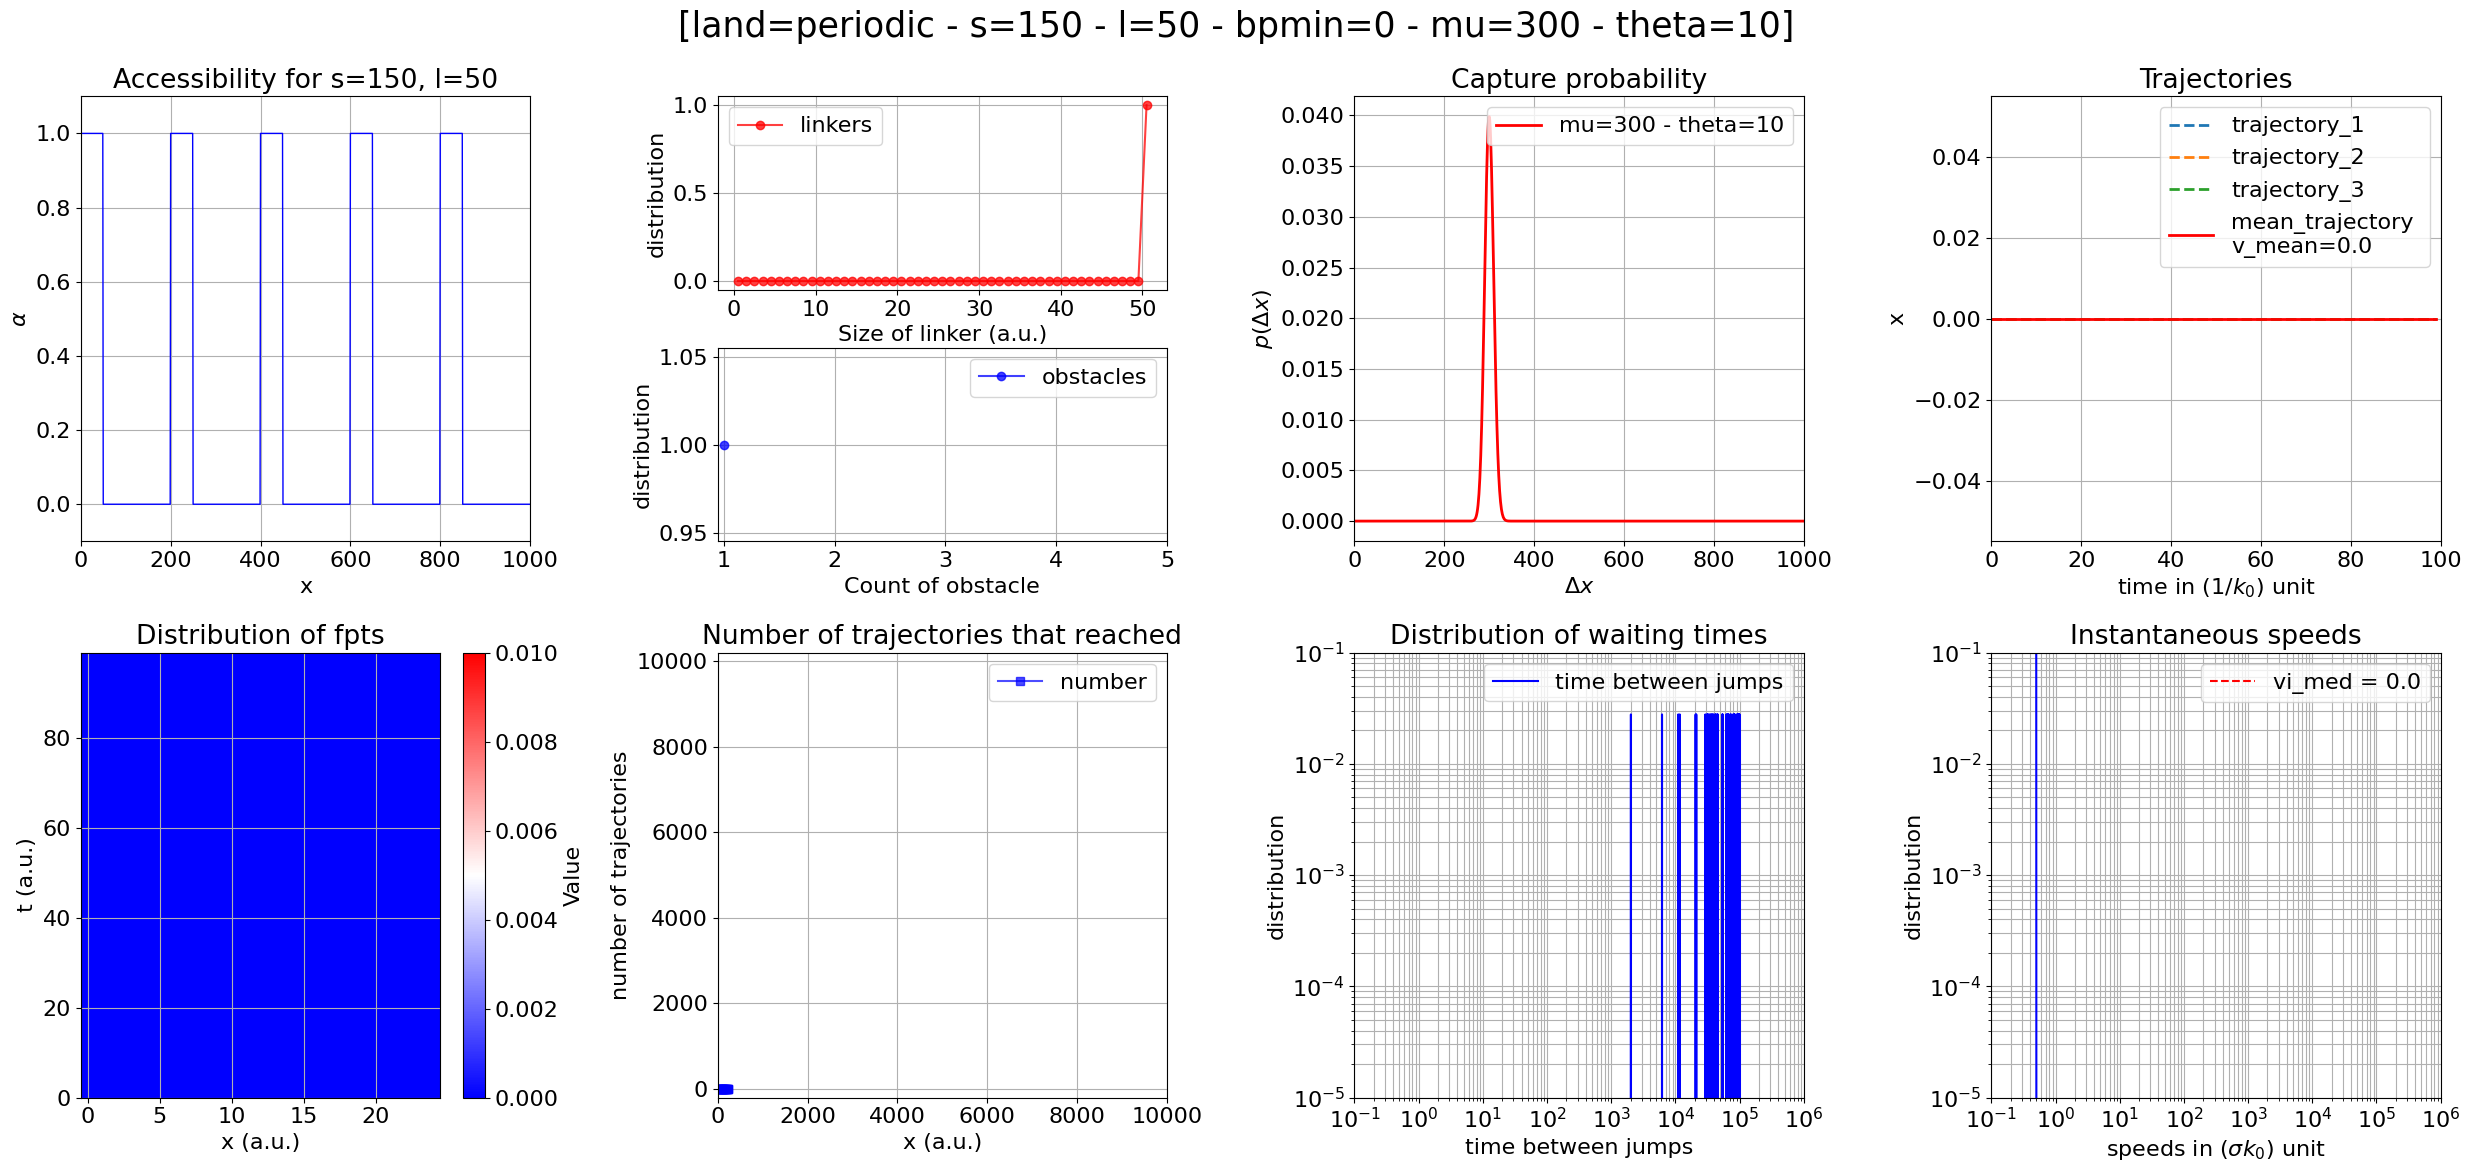

NaNs detected in one or more input arrays — skipping plot_fitting_summary.


<Figure size 640x480 with 0 Axes>

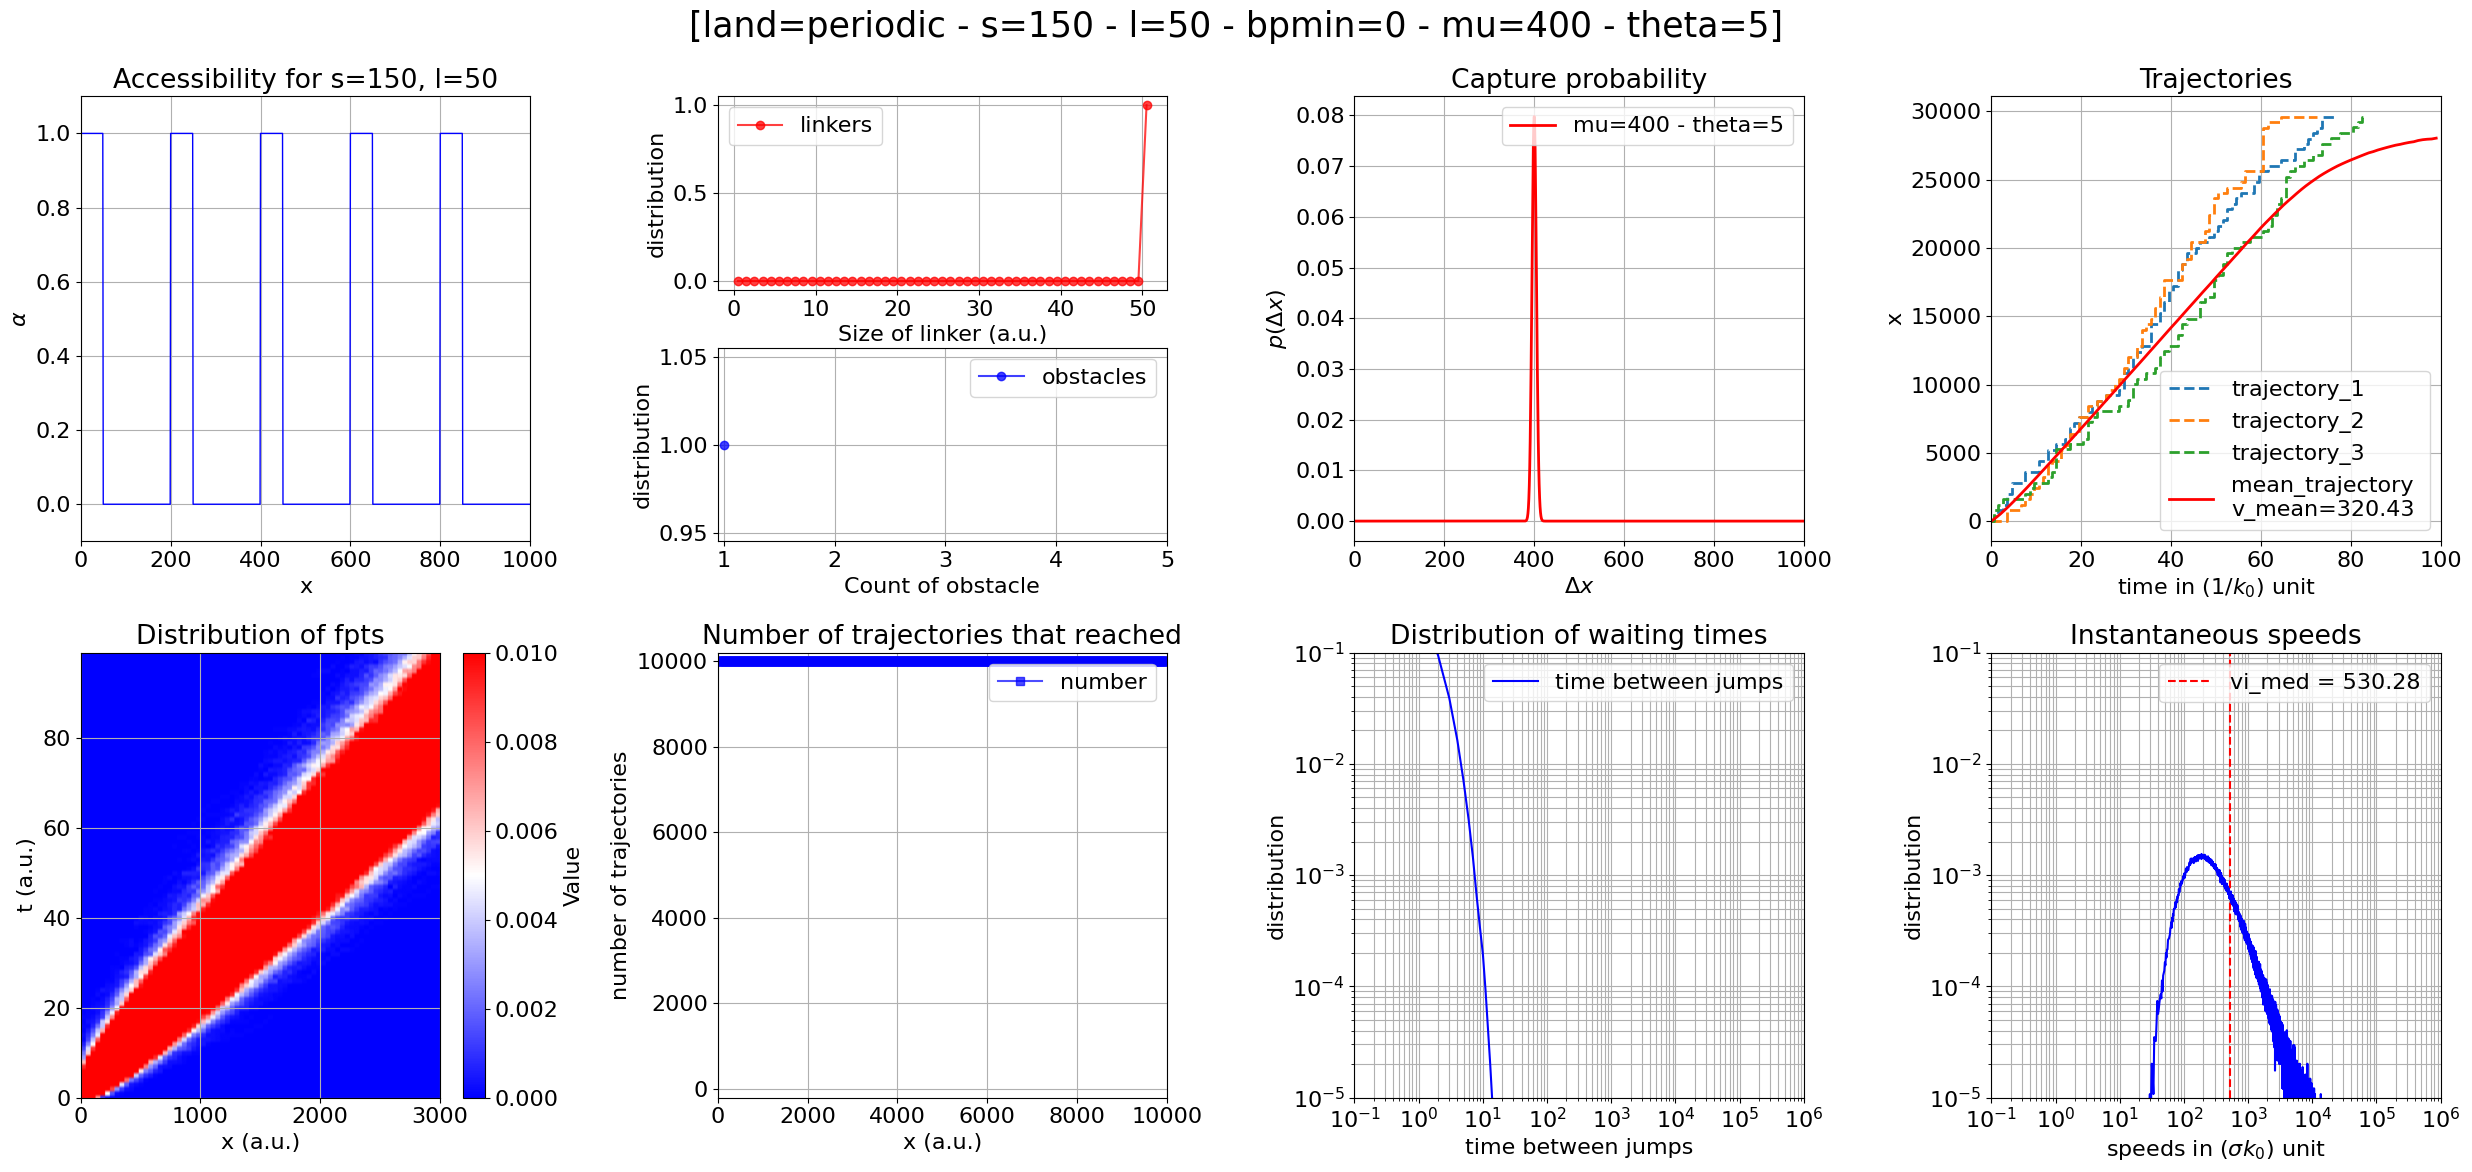

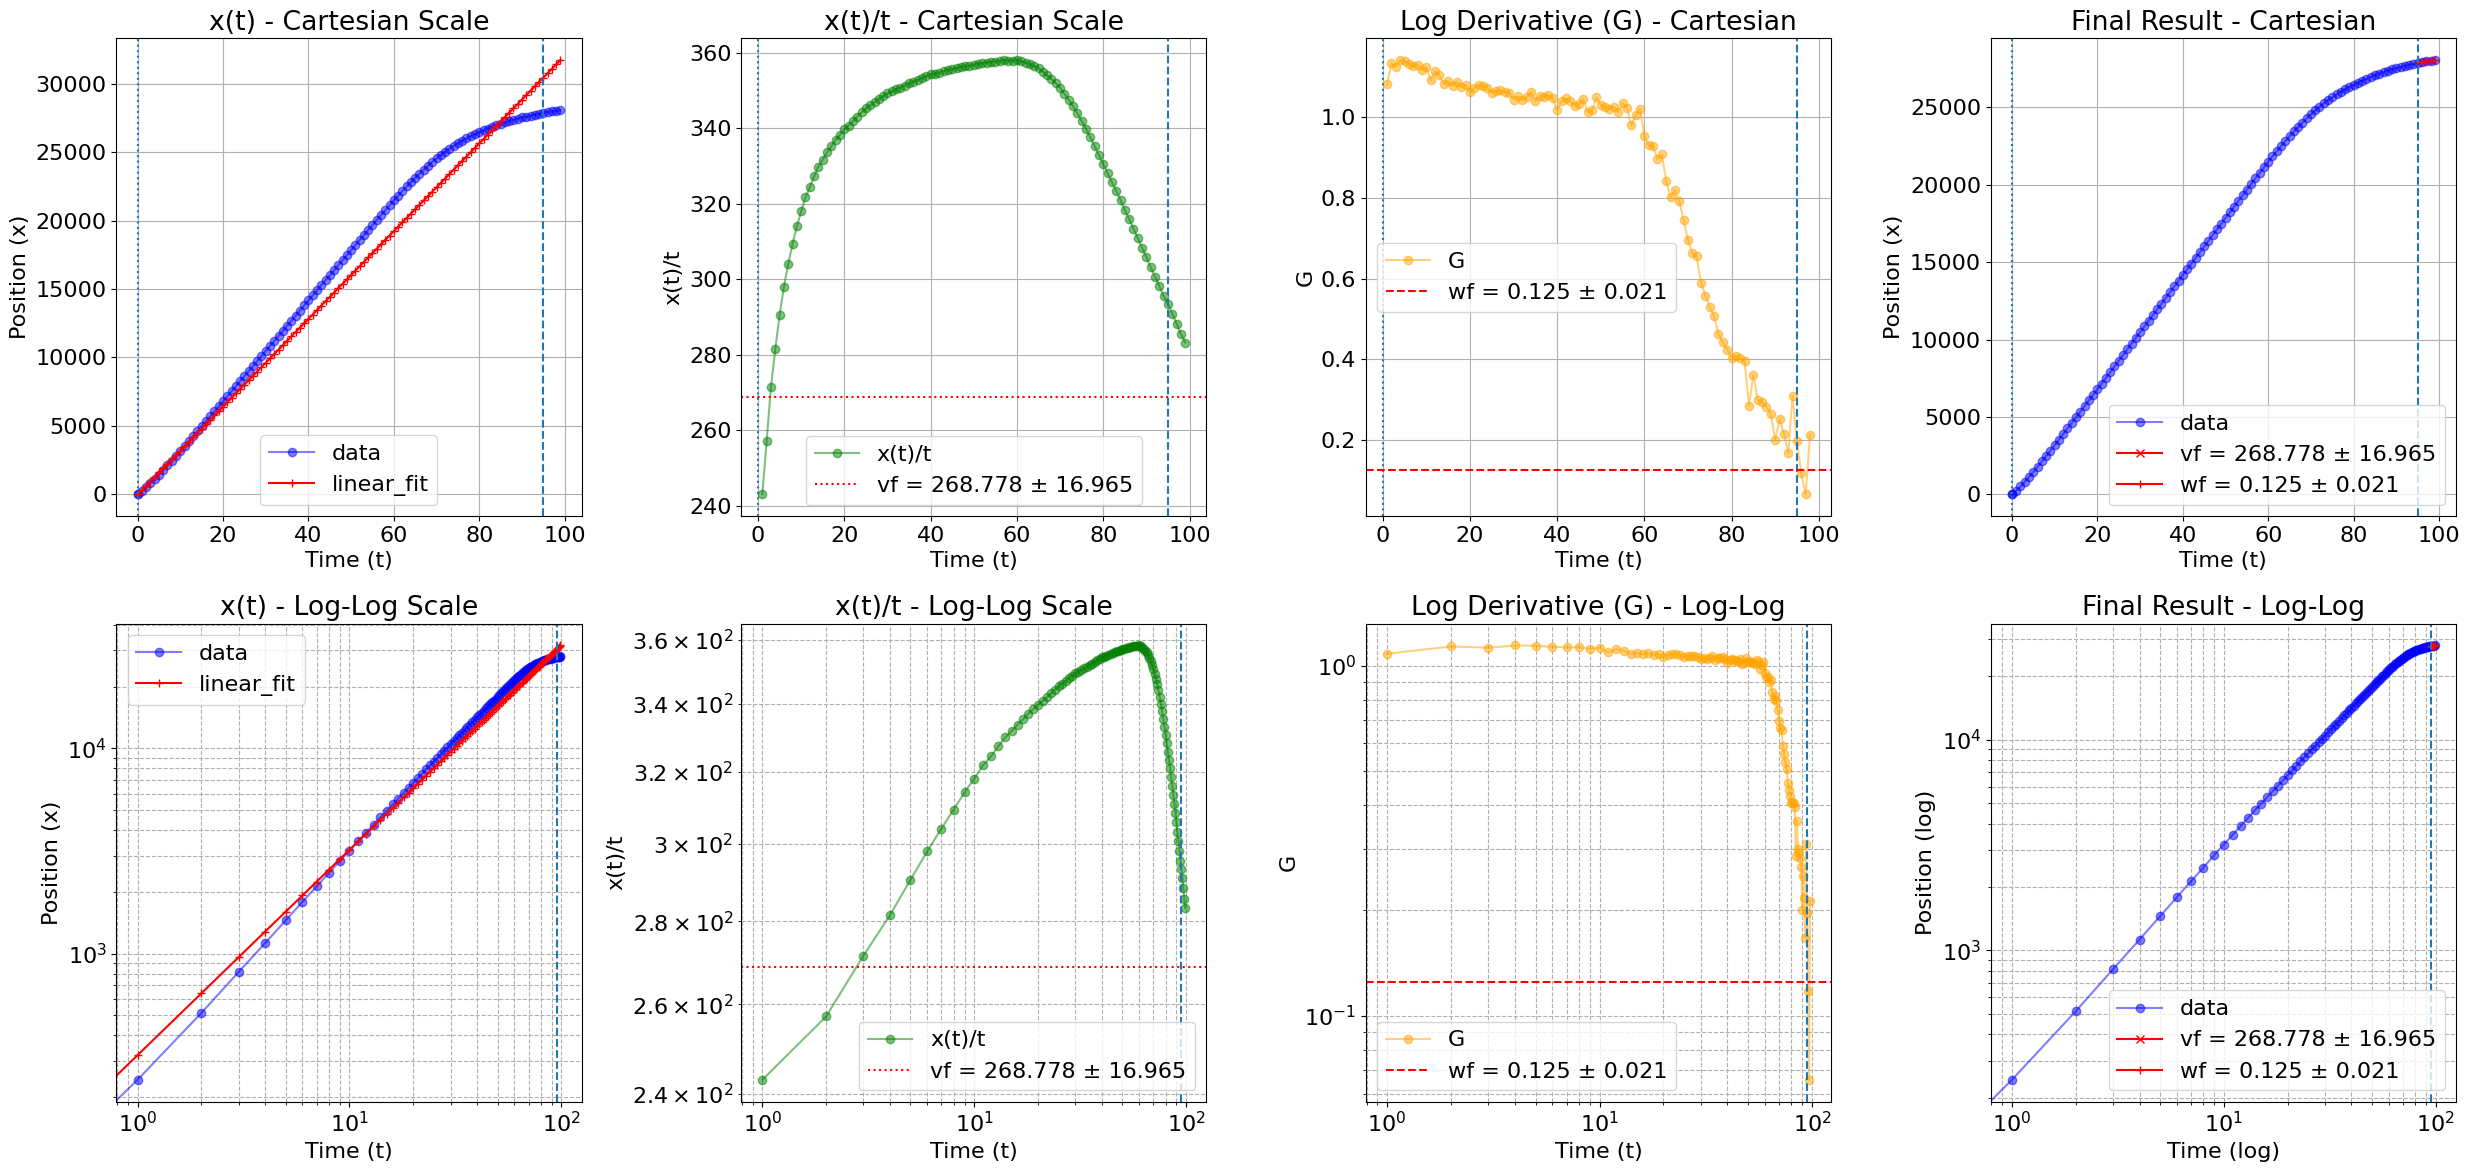

<Figure size 640x480 with 0 Axes>

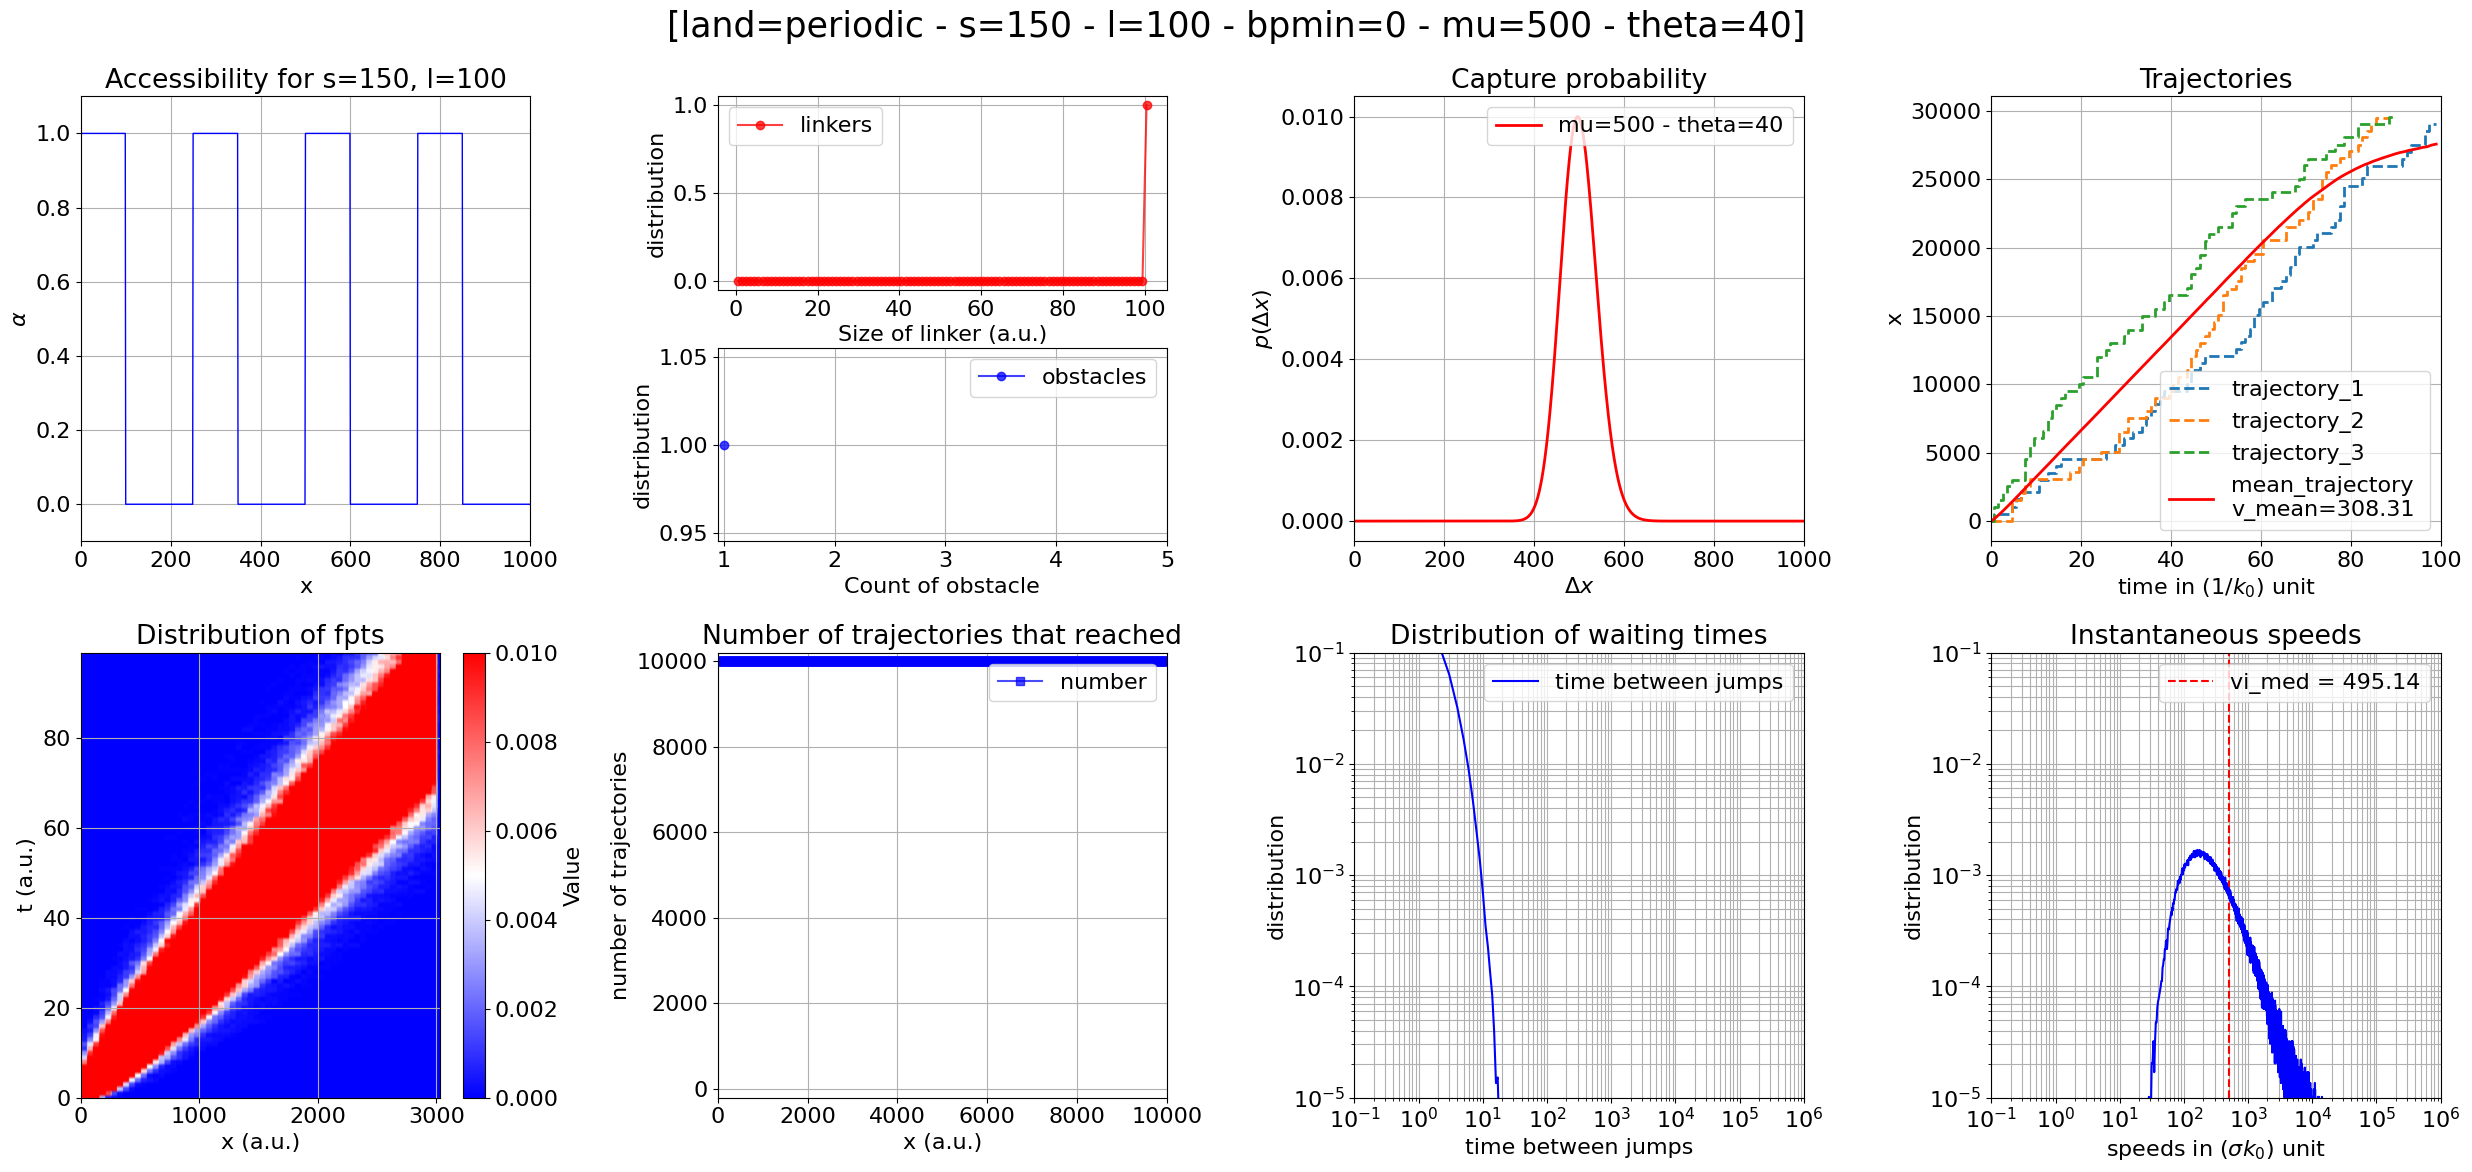

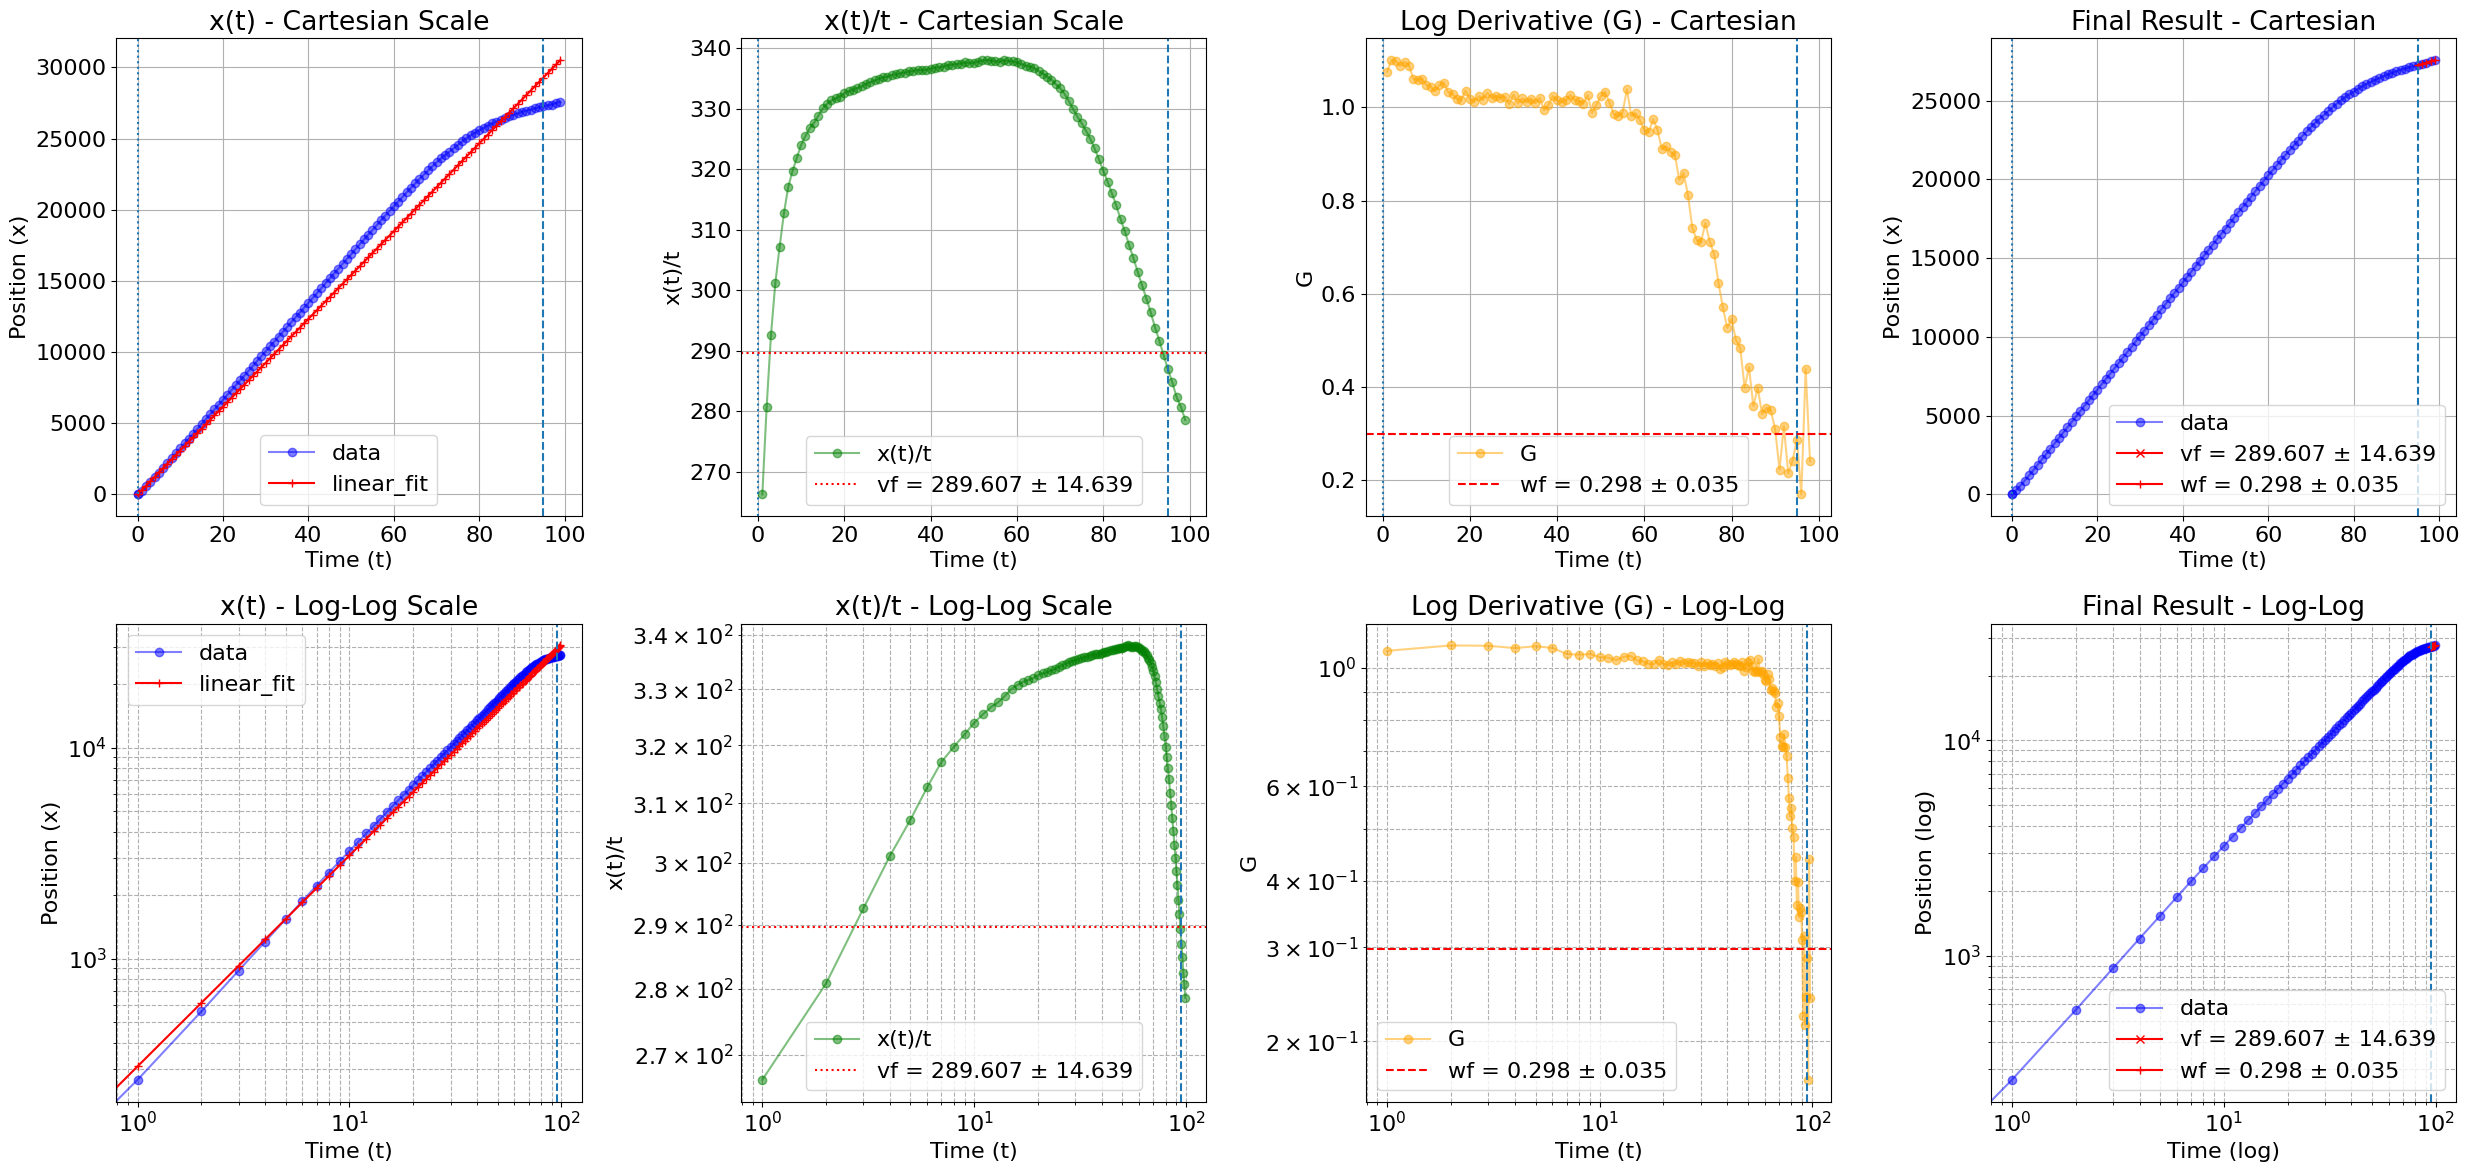

<Figure size 640x480 with 0 Axes>

In [7]:
list_sim_data = [
    sim_data_1,
    sim_data_2,
    sim_data_3,
    sim_data_4,
]

for sim_data in list_sim_data:

    fig, axes = plt.subplots(2, 4, figsize=(25, 12))
    axes = axes.flatten()

    plot_functions = [
        (nclp.plot_obstacle, (
            sim_data.s,
            sim_data.l,
            sim_data.origin,
            sim_data.alpha_mean_a,
        )),
        (nclp.plot_obs_linker_distrib, (
            sim_data.s,
            sim_data.s_points,
            sim_data.s_distrib,
            sim_data.l_points,
            sim_data.l_distrib,
        )),
        (nclp.plot_probabilities, (
            sim_data.mu,
            sim_data.theta,
            sim_data.p,
        )),
        (nclp.plot_trajectories, (
            sim_data.tmax,
            sim_data.times,
            sim_data.results,
            sim_data.results_mean,
            sim_data.results_med,
            sim_data.results_std,
            sim_data.v_mean,
            sim_data.v_med,
        )),
        (nclp.plot_fpt_distrib_2d, (
            sim_data.fpt_distrib,
            sim_data.tmax,
            sim_data.bint,
        )),
        (nclp.plot_fpt_number, (
            sim_data.nt,
            sim_data.tmax,
            sim_data.fpt_number,
            sim_data.bint,
        )),
        (nclp.plot_waiting_times, (
            sim_data.tbj_points,
            sim_data.tbj_distrib,
        )),
        (nclp.plot_speed_distribution, (
            sim_data.vi_points,
            sim_data.vi_distrib,
            sim_data.vi_mean,
            sim_data.vi_med,
            sim_data.vi_mp,
        )),
    ]

    for ax, (plot_func, args) in zip(axes, plot_functions):
        plot_func(*args, ax=ax)

    fig.suptitle(
        f"[land={sim_data.land} - s={sim_data.s} - l={sim_data.l} - "
        f"bpmin={sim_data.bpmin} - mu={sim_data.mu} - theta={sim_data.theta}]",
        fontsize=25,
    )

    plt.tight_layout()
    plt.show()


    nclp.plot_fitting_summary(
    sim_data.times,
    sim_data.results_mean,
    sim_data.v_mean,
    sim_data.xt_over_t,
    sim_data.G,
    sim_data.vf,
    sim_data.vf_std,
    sim_data.Cf,
    sim_data.Cf_std,
    sim_data.wf,
    sim_data.wf_std,
    bound_low=sim_data.bound_l,
    bound_high=sim_data.bound_h,
    rf=3,
    text_size=16,
    ax=None
)

    plt.tight_layout()
    plt.show()  

# Single

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(25, 12))
axes = axes.flatten()

plot_functions = [
    (nclp.plot_obstacle, (sim_data.s, sim_data.l, sim_data.origin, sim_data.alpha_mean_a)),
    (nclp.plot_obs_linker_distrib, (sim_data.s, sim_data.s_points, sim_data.s_distrib, sim_data.l_points, sim_data.l_distrib)),
    (nclp.plot_probabilities, (sim_data.mu, sim_data.theta, sim_data.p)),
    (nclp.plot_trajectories, (sim_data.tmax, sim_data.times, sim_data.results, sim_data.results_mean, sim_data.results_med, sim_data.results_std, sim_data.v_mean, sim_data.v_med)),
    (nclp.plot_fpt_distrib_2d, (sim_data.fpt_distrib, sim_data.tmax, sim_data.bint)),
    (nclp.plot_fpt_number, (sim_data.nt, sim_data.tmax, sim_data.fpt_number, sim_data.bint)),
    (nclp.plot_waiting_times, (sim_data.tbj_points, sim_data.tbj_distrib)),
    (nclp.plot_speed_distribution, (sim_data.vi_points, sim_data.vi_distrib, sim_data.vi_mean, sim_data.vi_med, sim_data.vi_mp))
]

for i, (plot_func, args) in enumerate(plot_functions):
    plot_func(*args, ax=axes[i])

plt.suptitle(
    f'[alpha={sim_data.land} - s={sim_data.s} - l={sim_data.l} - bpmin={sim_data.bpmin} - mu={sim_data.mu} - theta={sim_data.theta}]',
    fontsize=25
)
plt.tight_layout()
plt.show()

In [ ]:
plot_functions = [
    (nclp.plot_obstacle, (sim_data.s, sim_data.l, sim_data.origin, sim_data.alpha_mean_a)),
    (nclp.plot_probabilities, (sim_data.mu, sim_data.theta, sim_data.p)),
    # (nclp.plot_linker_view, (sim_data.link_view,)),
    (nclp.plot_trajectories, (sim_data.tmax, sim_data.times, sim_data.results, sim_data.results_mean, sim_data.results_med, sim_data.results_std, sim_data.v_mean, sim_data.v_med)),
    (nclp.plot_speed_distribution, (sim_data.vi_points, sim_data.vi_distrib, sim_data.vi_mean, sim_data.vi_med, sim_data.vi_mp))
]

fig, axes = plt.subplots(1, len(plot_functions), figsize=(25, 6))
axes = axes.flatten()

for i, (plot_func, args) in enumerate(plot_functions):
    plot_func(*args, ax=axes[i])

plt.suptitle(
    f'[alpha={sim_data.alpha_choice} - s={sim_data.s} - l={sim_data.l} - bpmin={sim_data.bpmin} - mu={sim_data.mu} - theta={sim_data.theta}]',
    fontsize=25
)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
f, args = (nclp.plot_obs_linker_distrib, (sim_data.s, sim_data.obs_points, sim_data.obs_distrib, sim_data.link_points, sim_data.link_distrib))
f(*args, ax=ax)
plt.show()


fig, ax = plt.subplots(figsize=(8, 4))
f, args = (nclp.plot_linker_view, (sim_data.link_view,))
f(*args, ax=ax)
plt.show()


plot_functions = [
    (nclp.plot_linker_view, (sim_data.link_view,)),
    (nclp.plot_speed_distribution, (sim_data.vi_points, sim_data.vi_distrib, sim_data.vi_mean, sim_data.vi_med, sim_data.vi_mp))
]

fig, axes = plt.subplots(1, len(plot_functions), figsize=(14, 6))
axes = axes.flatten()

for i, (plot_func, args) in enumerate(plot_functions):
    plot_func(*args, ax=axes[i])

plt.suptitle(
    f'[alpha={sim_data.alpha_choice} - s={sim_data.s} - l={sim_data.l} - bpmin={sim_data.bpmin} - mu={sim_data.mu} - theta={sim_data.theta}]',
    fontsize=25
)
plt.tight_layout()
plt.show()

In [ ]:
nclp.plot_fitting_summary(
    sim_data.times,
    sim_data.results_mean,
    sim_data.v_mean,
    sim_data.xt_over_t,
    sim_data.G,
    sim_data.vf,
    sim_data.vf_std,
    sim_data.Cf,
    sim_data.Cf_std,
    sim_data.wf,
    sim_data.wf_std,
    bound_low=sim_data.bound_l,
    bound_high=sim_data.bound_h,
    rf=3,
    text_size=16,
    ax=None
)

plt.tight_layout()
plt.show()

# .